In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error

In [2]:
arquivo = "LW-DATASET.xlsx"

df = pd.read_excel(
    arquivo,
    sheet_name="Dataset Geral"
)

df.head()

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?
0,INC8654273,3 - Média,NaN,NaN,NaN,Team14,IC00001,2025-12-31 23:45:18,NaT,2025-12-31 23:45:32,14,NaN,Problem: Apache Busy Workers,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
1,INC8654270,4 - Baixa,NaN,NaN,NaN,Team14,IC00002,2025-12-31 23:39:36,NaT,2025-12-31 23:43:05,209,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
2,INC8654264,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:10,NaT,2025-12-31 23:25:00,110,NaN,Problem: Alarm Application Monitoring database...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
3,INC8654263,4 - Baixa,NaN,NaN,NaN,Team14,NaN,2025-12-31 23:23:07,NaT,2025-12-31 23:24:57,110,NaN,Problem: Alarm Application Monitoring coupons ...,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN
4,INC8654262,4 - Baixa,NaN,NaN,NaN,Team14,IC00003,2025-12-31 23:23:05,NaT,2025-12-31 23:23:47,42,NaN,Problem: Check Application Monitoring,NaN,Monitoramento,NaN,Sem Intervenção,NAO,NaN


onverte Aberto para data/hora,
mantém apenas prioridades 2 - Alta e 3 - Média,
mostra quantos incidentes ficaram no filtro

In [3]:
df["Aberto"] = pd.to_datetime(df["Aberto"], errors="coerce")

df_p23 = df[
    df["Prioridade"].isin(["2 - Alta", "3 - Média"])
].copy()

print("Total P2 + P3:", len(df_p23))

df_p23[["Número", "Prioridade", "Aberto"]].head()

Total P2 + P3: 57381


,Número,Prioridade,Aberto
0,INC8654273,3 - Média,2025-12-31 23:45:18
7,INC8654258,3 - Média,2025-12-31 23:19:10
19,INC8654229,3 - Média,2025-12-31 22:47:45
21,INC8654223,3 - Média,2025-12-31 22:42:29
22,INC8654222,3 - Média,2025-12-31 22:42:26


In [5]:
serie_2025_base = df_p23[
    df_p23["Aberto"].dt.year == 2025
].copy()

print("Total P2 + P3 em 2025:", len(serie_2025_base))

print("\nDistribuição por prioridade:")
print(serie_2025_base["Prioridade"].value_counts())

Total P2 + P3 em 2025: 56905

Distribuição por prioridade:
Prioridade
3 - Média    41260
2 - Alta     15645
Name: count, dtype: int64


In [6]:
serie_2025_base["Data"] = serie_2025_base["Aberto"].dt.date

serie_diaria = (
    serie_2025_base
    .groupby(["Data", "Prioridade"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

serie_diaria = serie_diaria.rename(columns={
    "2 - Alta": "P2",
    "3 - Média": "P3"
})

serie_diaria["TOTAL"] = serie_diaria["P2"] + serie_diaria["P3"]

serie_diaria["Data"] = pd.to_datetime(serie_diaria["Data"])

serie_diaria.head()

Prioridade,Data,P2,P3,TOTAL
0,2025-01-01,5,6,11
1,2025-01-02,5,38,43
2,2025-01-03,11,40,51
3,2025-01-04,139,10,149
4,2025-01-05,11,7,18


In [7]:
resultado_adf = adfuller(
    serie_diaria["TOTAL"].dropna()
)

print("Estatística ADF:", resultado_adf[0])
print("p-valor:", resultado_adf[1])

Estatística ADF: 0.6099940266006548
p-valor: 0.9878593916938772


/tmp/ipykernel_1347/4000398885.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf = adfuller(


In [8]:
serie_diaria["DIFERENCA_1"] = serie_diaria["TOTAL"].diff()

resultado_adf_diff = adfuller(
    serie_diaria["DIFERENCA_1"].dropna()
)

print("Estatística ADF após diferenciação:", resultado_adf_diff[0])
print("p-valor após diferenciação:", resultado_adf_diff[1])

Estatística ADF após diferenciação: -9.014008632935463
p-valor após diferenciação: 6.018690732149103e-15


/tmp/ipykernel_1347/3811932253.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  resultado_adf_diff = adfuller(


In [9]:
serie = serie_diaria["TOTAL"].astype(float).reset_index(drop=True)

treino = serie.iloc[:-30]
teste = serie.iloc[-30:]

modelos = [
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 1),
    (1, 1, 2)
]

resultados = []

for ordem in modelos:
    modelo = ARIMA(treino, order=ordem)
    ajustado = modelo.fit()

    previsao = ajustado.forecast(
        steps=len(teste)
    )

    mae = mean_absolute_error(
        teste,
        previsao
    )

    resultados.append({
        "ARIMA": ordem,
        "MAE": mae
    })

resultados_df = pd.DataFrame(resultados)

resultados_df.sort_values("MAE")

,ARIMA,MAE
0,"(1, 1, 0)",123.231279
1,"(0, 1, 1)",137.425103
4,"(1, 1, 2)",137.957487
2,"(1, 1, 1)",137.967100
3,"(2, 1, 1)",137.988291


In [10]:
modelo_final = ARIMA(
    serie_diaria["TOTAL"].astype(float),
    order=(1, 1, 0)
)

modelo_final = modelo_final.fit()

previsao_7dias = modelo_final.forecast(
    steps=7
)

datas_futuras = pd.date_range(
    start=serie_diaria["Data"].max() + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

resultado_previsao = pd.DataFrame({
    "Data": datas_futuras,
    "Previsao_Incidentes": previsao_7dias.values
})

resultado_previsao["Previsao_Incidentes"] = (
    resultado_previsao["Previsao_Incidentes"]
    .round()
    .astype(int)
)

resultado_previsao

,Data,Previsao_Incidentes
0,2026-01-01,429
1,2026-01-02,413
2,2026-01-03,419
3,2026-01-04,417
4,2026-01-05,418
5,2026-01-06,417
6,2026-01-07,417


In [11]:
d1 = resultado_previsao.iloc[0]["Previsao_Incidentes"]
d7 = resultado_previsao.iloc[-1]["Previsao_Incidentes"]
acumulado_7dias = resultado_previsao["Previsao_Incidentes"].sum()

print("Previsão D+1:", d1)
print("Previsão D+7:", d7)
print("Acumulado previsto em 7 dias:", acumulado_7dias)

Previsão D+1: 429
Previsão D+7: 417
Acumulado previsto em 7 dias: 2930


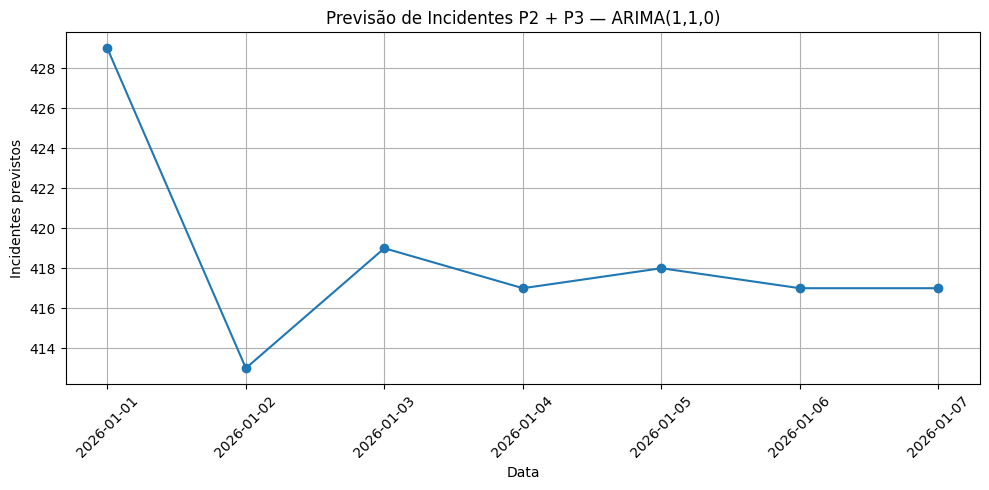

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    resultado_previsao["Data"],
    resultado_previsao["Previsao_Incidentes"],
    marker="o"
)

plt.title("Previsão de Incidentes P2 + P3 — ARIMA(1,1,0)")
plt.xlabel("Data")
plt.ylabel("Incidentes previstos")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [13]:
serie_diaria.to_csv(
    "serie_diaria_2025.csv",
    index=False
)

resultado_previsao.to_csv(
    "previsoes_2026.csv",
    index=False
)

print("Arquivos gerados com sucesso.")

Arquivos gerados com sucesso.


## Conclusão

O projeto LWPredictOps utilizou dados históricos de incidentes P2 e P3 de 2025 para construir uma série temporal diária e avaliar diferentes modelos ARIMA.

O modelo ARIMA(1,1,0) apresentou o menor MAE, com valor aproximado de 123,23.

A previsão final para os primeiros sete dias de 2026 apresentou:

- D+1: 429 incidentes
- D+7: 417 incidentes
- Acumulado previsto em 7 dias: 2.930 incidentes

Os resultados foram utilizados no dashboard desenvolvido em Power BI para apoio ao planejamento operacional.